# Informe Churn Modelling (Exploración)

## Importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

## Lectura de archivo desde Github

In [2]:
url = "https://raw.githubusercontent.com/javisagredo-dev/Evaluacion_Parcial_4/main/data/raw/Churn_Modelling.csv"
df = pd.read_csv(url)

## EDA

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.shape

(10000, 14)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [6]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df_exploracion = df.drop(columns=['RowNumber', 'CustomerId', 'Surname']).copy()

### Tratamiento de datos faltantes

Se realizó una verificación de valores nulos mediante df.isnull().sum() y de registros duplicados mediante df.duplicated().sum(), confirmando que el dataset no presenta valores faltantes ni filas duplicadas en ninguna de sus 14 columnas. Dado que el conjunto de datos se encuentra completo, no fue necesario aplicar técnicas de imputación (como reemplazo por media, mediana, moda o métodos basados en vecinos como KNN). Esta verificación constituye en sí misma una etapa relevante del preprocesamiento, ya que garantiza la integridad de los datos antes de proceder con las siguientes etapas de transformación (escalamiento, codificación e ingeniería de características).

Adicionalmente, se eliminaron las variables `RowNumber`, `CustomerId` y `Surname`, ya que corresponden a identificadores sin valor predictivo para el modelo y no aportan información relevante para las etapas posteriores de análisis y preprocesamiento.

## Visualización de datos

### Variables categóricas

In [10]:
display(df_exploracion['Geography'].value_counts())
display(df_exploracion['Gender'].value_counts())

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Gender
Male      5457
Female    4543
Name: count, dtype: int64

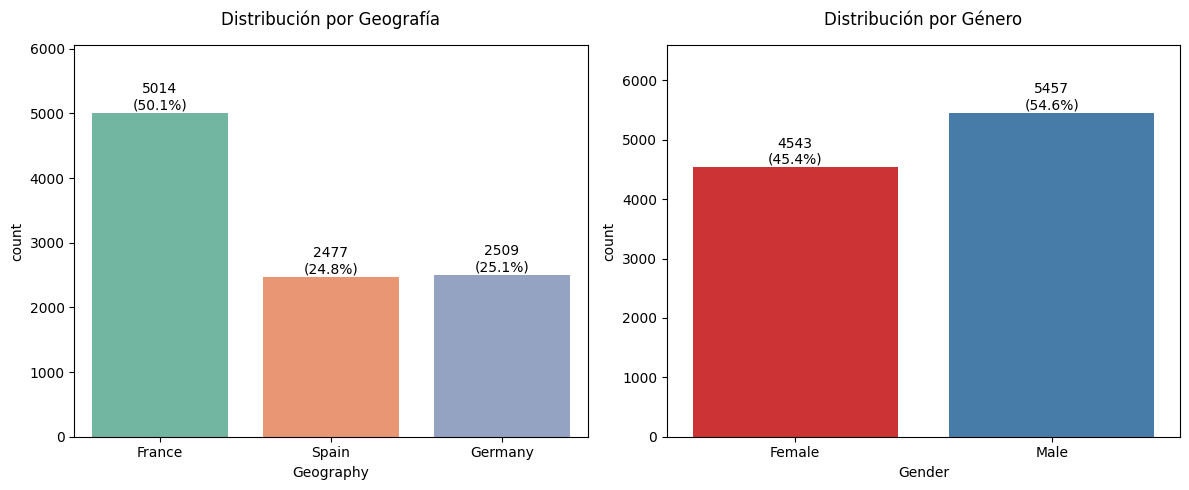

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Geography
sns.countplot(data=df_exploracion, x='Geography', hue='Geography', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Distribución por Geografía', pad=15)
total_geo = len(df_exploracion)
for p in axes[0].patches:
    count = int(p.get_height())
    pct = 100 * count / total_geo
    axes[0].annotate(f'{count}\n({pct:.1f}%)', (p.get_x() + p.get_width() / 2, p.get_height()),
                      ha='center', va='bottom')
axes[0].set_ylim(0, axes[0].get_ylim()[1] * 1.15)

# Gender
sns.countplot(data=df_exploracion, x='Gender', hue='Gender', palette='Set1', legend=False, ax=axes[1])
axes[1].set_title('Distribución por Género', pad=15)
total_gen = len(df_exploracion)
for p in axes[1].patches:
    count = int(p.get_height())
    pct = 100 * count / total_gen
    axes[1].annotate(f'{count}\n({pct:.1f}%)', (p.get_x() + p.get_width() / 2, p.get_height()),
                      ha='center', va='bottom')
axes[1].set_ylim(0, axes[1].get_ylim()[1] * 1.15)

plt.tight_layout()
plt.show()

### Variables numéricas continuas/discretas

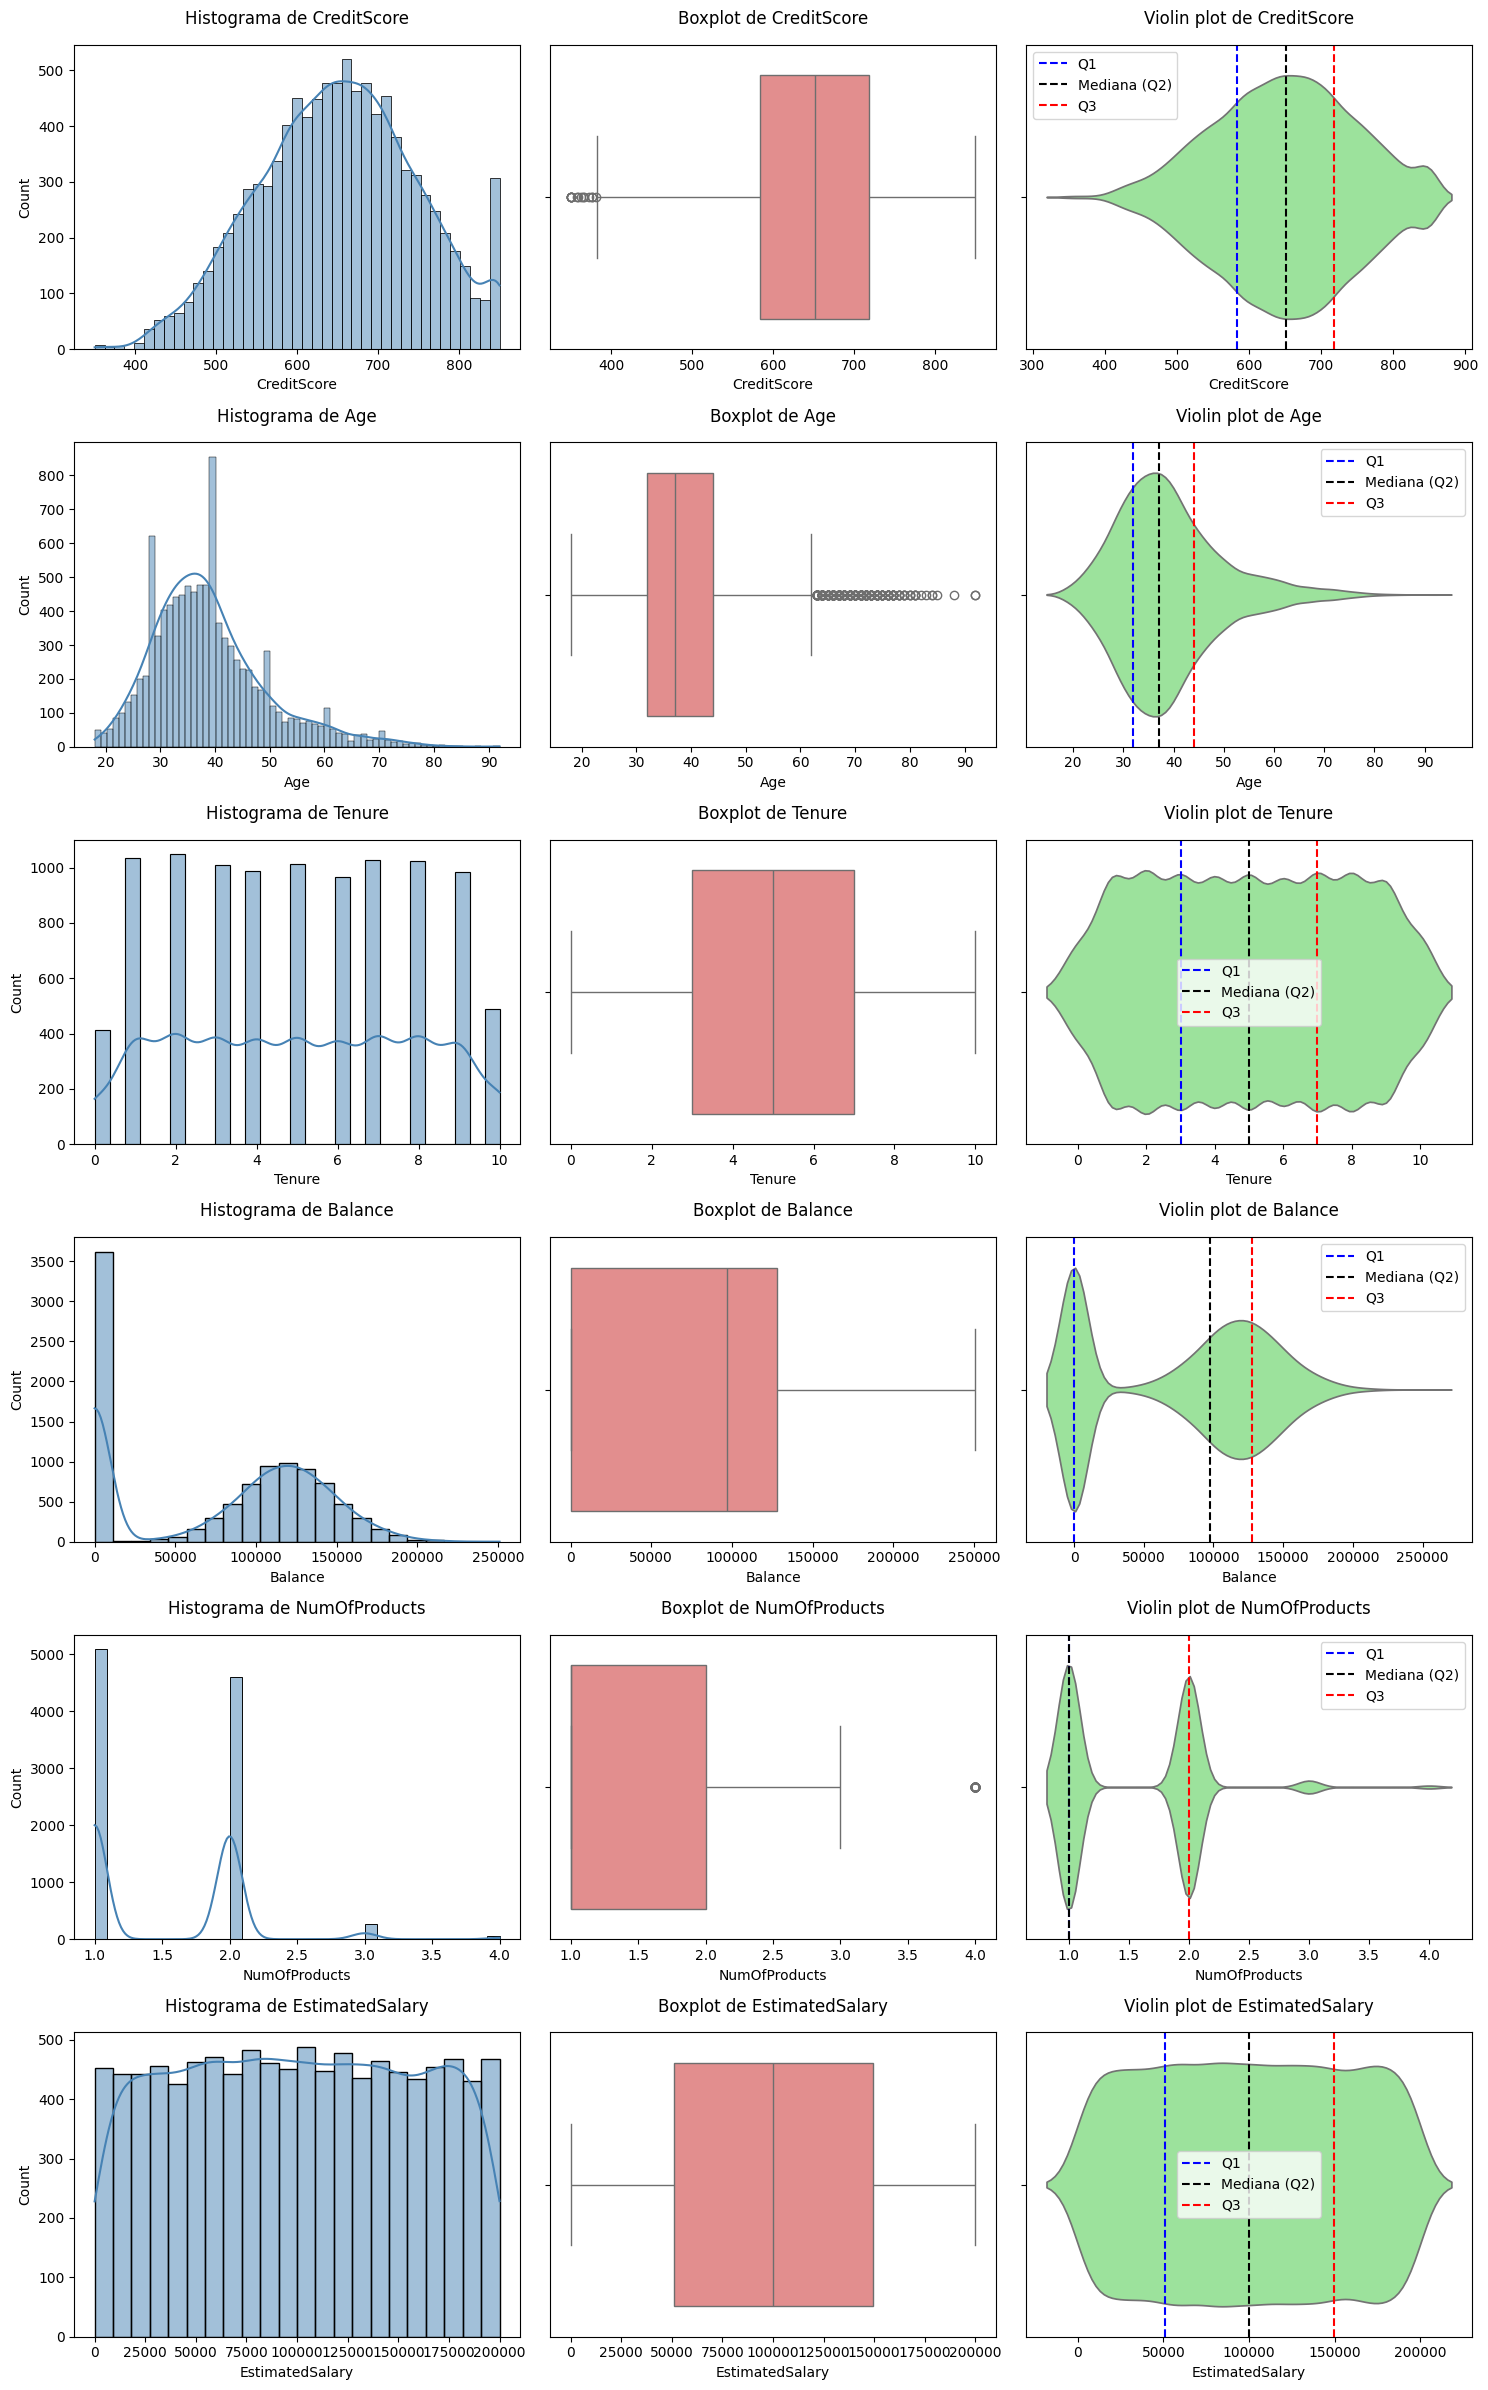

In [12]:
numericas = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

fig, axes = plt.subplots(len(numericas), 3, figsize=(15, 4 * len(numericas)))

for i, col in enumerate(numericas):
    sns.histplot(data=df_exploracion, x=col, kde=True, color='steelblue', ax=axes[i, 0])
    axes[i, 0].set_title(f'Histograma de {col}', pad=15)

    sns.boxplot(data=df_exploracion, x=col, color='lightcoral', ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot de {col}', pad=15)

    sns.violinplot(data=df_exploracion, x=col, color='lightgreen', inner=None, ax=axes[i, 2])
    q1, q2, q3 = df_exploracion[col].quantile([0.25, 0.5, 0.75])
    axes[i, 2].axvline(q1, color='blue', linestyle='--', label='Q1')
    axes[i, 2].axvline(q2, color='black', linestyle='--', label='Mediana (Q2)')
    axes[i, 2].axvline(q3, color='red', linestyle='--', label='Q3')
    axes[i, 2].set_title(f'Violin plot de {col}', pad=15)
    axes[i, 2].legend()

plt.tight_layout()
plt.show()

### Variables booleanas

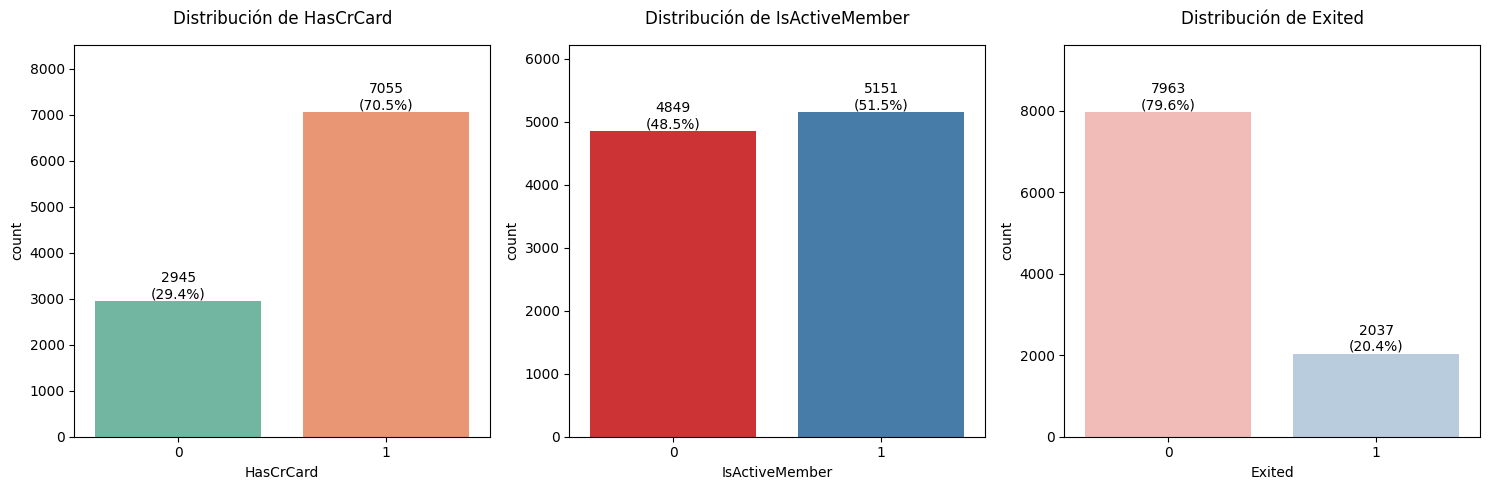

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

booleanas = ['HasCrCard', 'IsActiveMember', 'Exited']
colores = ['Set2', 'Set1', 'Pastel1']

for i, (col, paleta) in enumerate(zip(booleanas, colores)):
    sns.countplot(data=df_exploracion, x=col, hue=col, palette=paleta, legend=False, ax=axes[i])
    axes[i].set_title(f'Distribución de {col}', pad=15)
    total = len(df_exploracion)
    for p in axes[i].patches:
        count = int(p.get_height())
        pct = 100 * count / total
        axes[i].annotate(f'{count}\n({pct:.1f}%)', (p.get_x() + p.get_width() / 2, p.get_height()),
                          ha='center', va='bottom')
    axes[i].set_ylim(0, axes[i].get_ylim()[1] * 1.15)

plt.tight_layout()
plt.show()

## Análisis comparativo: clientes que abandonaron vs. clientes que permanecen

In [14]:
df_exited = df_exploracion[df_exploracion['Exited'] == 1]

display(df_exited.describe())

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,2037.000000,2037.000000,2037.000000,2037.000000,2037.000000,2037.000000,2037.000000,2037.000000,2037.0
mean,645.351497,44.837997,4.932744,91108.539337,1.475209,0.699067,0.360825,101465.677531,1.0
std,100.321503,9.761562,2.936106,58360.794816,0.801521,0.458776,0.480358,57912.418071,0.0
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,1.0
25%,578.000000,38.000000,2.000000,38340.020000,1.000000,0.000000,0.000000,51907.720000,1.0
50%,646.000000,45.000000,5.000000,109349.290000,1.000000,1.000000,0.000000,102460.840000,1.0
75%,716.000000,51.000000,8.000000,131433.330000,2.000000,1.000000,1.000000,152422.910000,1.0
max,850.000000,84.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199808.100000,1.0


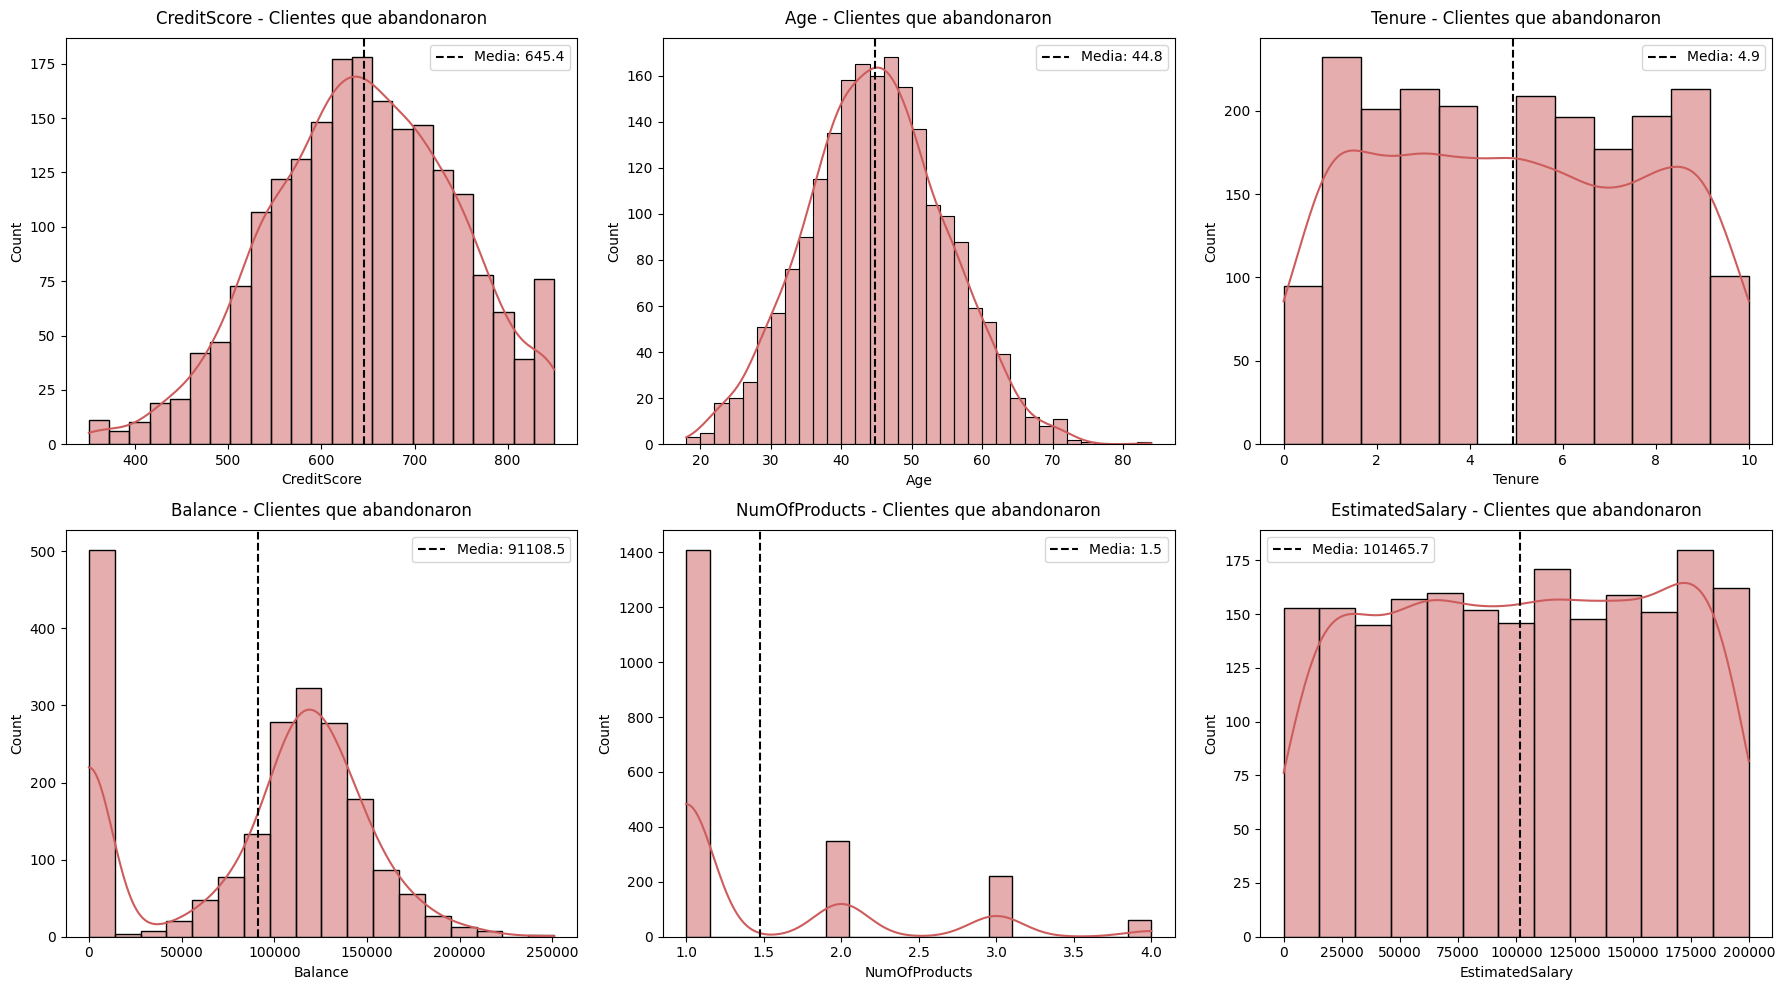

In [15]:
numericas = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numericas):
    sns.histplot(data=df_exited, x=col, kde=True, color='indianred', ax=axes[i])
    axes[i].set_title(f'{col} - Clientes que abandonaron', pad=10)
    axes[i].axvline(df_exited[col].mean(), color='black', linestyle='--', label=f'Media: {df_exited[col].mean():.1f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

In [16]:
comparacion = df_exploracion.groupby('Exited')[['CreditScore', 'Age', 'Tenure', 'Balance',
                                                   'NumOfProducts', 'EstimatedSalary']].mean().round(2)
comparacion.index = ['No abandonó (0)', 'Abandonó (1)']

diferencia = ((comparacion.loc['Abandonó (1)'] - comparacion.loc['No abandonó (0)']) /
              comparacion.loc['No abandonó (0)'] * 100).round(1)

tabla_final = comparacion.T
tabla_final['Diferencia (%)'] = diferencia
tabla_final = tabla_final.sort_values('Diferencia (%)', key=abs, ascending=False)

display(tabla_final.style.background_gradient(subset=['Diferencia (%)'], cmap='RdYlGn_r')
        .format('{:.2f}'))

,No abandonó (0),Abandonó (1),Diferencia (%)
Balance,72745.30,91108.54,25.20
Age,37.41,44.84,19.90
NumOfProducts,1.54,1.48,-3.90
Tenure,5.03,4.93,-2.00
EstimatedSalary,99738.39,101465.68,1.70
CreditScore,651.85,645.35,-1.00


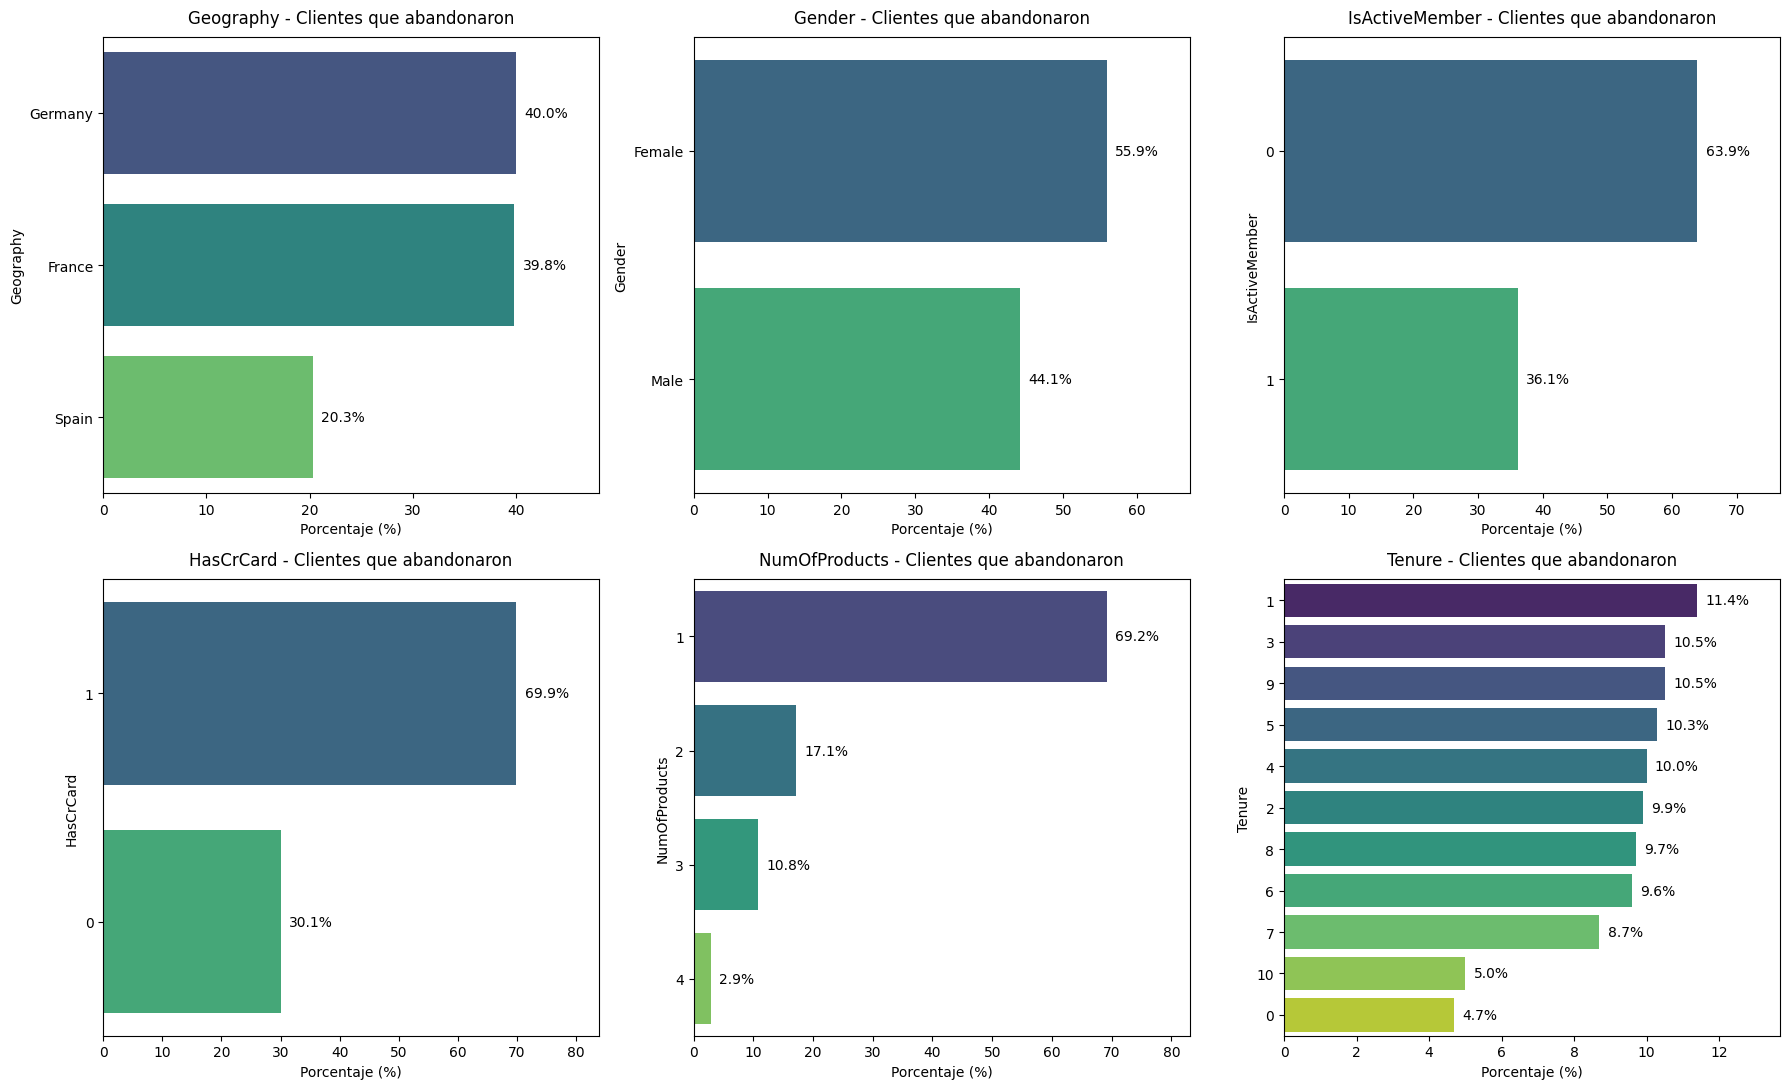

In [17]:
cols_categoricas = ['Geography', 'Gender', 'IsActiveMember', 'HasCrCard', 'NumOfProducts', 'Tenure']

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, col in enumerate(cols_categoricas):
    tabla = df_exited[col].value_counts(normalize=True).mul(100).round(1).sort_values(ascending=False)
    sns.barplot(x=tabla.values, y=tabla.index.astype(str), hue=tabla.index.astype(str),
                palette='viridis', legend=False, ax=axes[i])
    axes[i].set_title(f'{col} - Clientes que abandonaron', pad=10)
    axes[i].set_xlabel('Porcentaje (%)')
    axes[i].set_xlim(0, tabla.values.max() * 1.2)
    for j, v in enumerate(tabla.values):
        axes[i].text(v + tabla.values.max() * 0.02, j, f'{v}%', va='center')

plt.tight_layout()
plt.show()

### Correlación

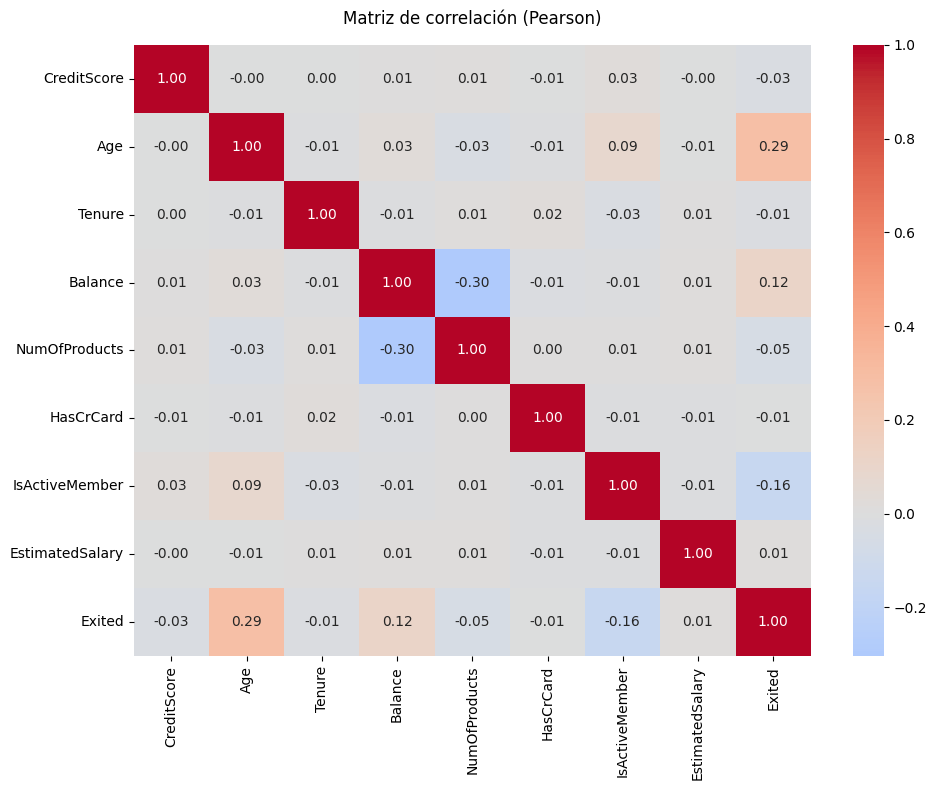

,Correlación (Pearson),Nivel
Age,0.285323,Débil
IsActiveMember,-0.156128,Débil
Balance,0.118533,Débil
NumOfProducts,-0.047820,Insignificante
CreditScore,-0.027094,Insignificante
Tenure,-0.014001,Insignificante
EstimatedSalary,0.012097,Insignificante
HasCrCard,-0.007138,Insignificante


In [18]:
numericas_corr = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
                   'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

corr = df_exploracion[numericas_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación (Pearson)', pad=15)
plt.tight_layout()
plt.show()

correlaciones = corr['Exited'].drop('Exited')

def nivel_correlacion(valor):
    valor = abs(valor)
    if valor < 0.10:
        return 'Insignificante'
    elif valor < 0.30:
        return 'Débil'
    elif valor < 0.50:
        return 'Moderada'
    elif valor < 0.70:
        return 'Fuerte'
    else:
        return 'Muy fuerte'

tabla_pearson = pd.DataFrame({
    'Correlación (Pearson)': correlaciones,
    'Nivel': correlaciones.apply(nivel_correlacion)
}).sort_values('Correlación (Pearson)', key=abs, ascending=False)

display(tabla_pearson)

In [19]:
def cramers_v(col, target='Exited'):
    tabla_contingencia = pd.crosstab(df_exploracion[col], df_exploracion[target])
    chi2, p, dof, expected = chi2_contingency(tabla_contingencia)
    n = tabla_contingencia.sum().sum()
    min_dim = min(tabla_contingencia.shape) - 1
    v = np.sqrt(chi2 / (n * min_dim))
    return chi2, p, v

resultados = []
for col in ['Geography', 'Gender']:
    chi2, p, v = cramers_v(col)
    resultados.append({'Variable': col, 'Chi2': round(chi2, 2), 'p-value': round(p, 4), "Cramér's V": round(v, 3)})

tabla_cramers = pd.DataFrame(resultados)
display(tabla_cramers)

,Variable,Chi2,p-value,Cramér's V
0,Geography,301.26,0.0,0.174
1,Gender,112.92,0.0,0.106


In [20]:
def nivel_asociacion(valor):
    valor = abs(valor)
    if valor < 0.10:
        return 'Insignificante'
    elif valor < 0.30:
        return 'Débil'
    elif valor < 0.50:
        return 'Moderada'
    elif valor < 0.70:
        return 'Fuerte'
    else:
        return 'Muy fuerte'

# Tabla Pearson (numéricas y booleanas)
resumen_pearson = tabla_pearson.reset_index().rename(columns={
    'index': 'Variable',
    'Correlación (Pearson)': 'Asociación',
    'Nivel': 'Nivel'
})
resumen_pearson['Método'] = 'Pearson'

# Tabla Cramér's V (categóricas nominales)
resumen_cramers = tabla_cramers[['Variable', "Cramér's V"]].rename(columns={"Cramér's V": 'Asociación'})
resumen_cramers['Nivel'] = resumen_cramers['Asociación'].apply(nivel_asociacion)
resumen_cramers['Método'] = "Cramér's V"

# Combinar y ordenar
resumen_final = pd.concat([resumen_pearson, resumen_cramers], ignore_index=True)
resumen_final = resumen_final.sort_values('Asociación', key=abs, ascending=False).reset_index(drop=True)

display(resumen_final[['Variable', 'Método', 'Asociación', 'Nivel']])

,Variable,Método,Asociación,Nivel
0,Age,Pearson,0.285323,Débil
1,Geography,Cramér's V,0.174000,Débil
2,IsActiveMember,Pearson,-0.156128,Débil
3,Balance,Pearson,0.118533,Débil
4,Gender,Cramér's V,0.106000,Débil
5,NumOfProducts,Pearson,-0.047820,Insignificante
6,CreditScore,Pearson,-0.027094,Insignificante
7,Tenure,Pearson,-0.014001,Insignificante
8,EstimatedSalary,Pearson,0.012097,Insignificante
9,HasCrCard,Pearson,-0.007138,Insignificante
